# Conjuntos de Entrenamiento y Prueba

In [ ]:
import pandas as pdhousing = pd.read_csv("./data/housing.csv")

Normalmente se separa una parte de los datos para usarla como conjunto de prueba (***test set***), y el modelo se entrena con el resto (***train set***). Esto evita el **sobreajuste (overfitting)**, que ocurre cuando el modelo se ajusta demasiado a los datos de entrenamiento y no generaliza bien a datos nuevos. Si el error en el conjunto de entrenamiento es bajo y en el de prueba es alto, el modelo está sobreajustado.

Lo habitual es usar el 20% de los datos para el conjunto de prueba, aunque esto depende del tamaño del dataset. Cuanto mayor sea el dataset, menos datos necesitaremos para el conjunto de prueba.

> **Nota sobre reproducibilidad:** El muestreo aleatorio que se muestra a continuación usa el generador de números aleatorios de NumPy sin fijar ninguna semilla, por lo que cada ejecución produce resultados distintos. Esto es intencional para demostrar la variabilidad del muestreo aleatorio. El enfoque con scikit-learn que se muestra más adelante demuestra cómo usar `random_state` para obtener resultados reproducibles.

## Muestreo aleatorio con NumPy

In [ ]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    ''' Baraja los datos y los divide en conjuntos de entrenamiento y prueba según la proporción indicada.

        Parámetros
        ----------
        data: pandas.DataFrame
            DataFrame con los datos que se quieren dividir
        test_ratio: float
            Proporción (entre 0 y 1) de datos que se usarán para prueba (el resto irá a entrenamiento)

        Devuelve
        -------
        train_set: pandas.DataFrame
            DataFrame con los datos de entrenamiento
        test_set: pandas.DataFrame
            DataFrame con los datos de prueba
    '''
    shuffled_indices = np.random.permutation(len(data))  # genera índices aleatoriamente
    test_set_size = int(len(data) * test_ratio)           # calcula el número de muestras que irán al conjunto de prueba
    test_indices = shuffled_indices[:test_set_size]       # selecciona los índices para el conjunto de prueba
    train_indices = shuffled_indices[test_set_size:]      # selecciona los índices para el conjunto de entrenamiento
    return data.iloc[train_indices], data.iloc[test_indices]  # devuelve los conjuntos de entrenamiento y prueba

In [ ]:
train_set, test_set = shuffle_and_split_data(housing, 0.2) # generate train and test sets (20% for test)len(train_set), len(test_set)

(16512, 4128)

## Muestreo aleatorio con scikit-learn

Lo mismo puede hacerse directamente con la función `train_test_split` de scikit-learn:

In [ ]:
from sklearn.model_selection import train_test_splittrain_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)len(train_set), len(test_set)

(16512, 4128)

En este ejemplo también se pasa el argumento `random_state` para que el resultado sea reproducible.

Hay que recordar que los ordenadores generan números pseudoaleatorios a partir de una [semilla aleatoria](https://es.wikipedia.org/wiki/Semilla_aleatoria) que normalmente varía en cada ejecución (así es precisamente como se consigue la aleatoriedad), siendo una de las más usadas el tiempo del sistema en milisegundos en el momento de la ejecución. Por tanto, si no se fija la semilla, cada vez que se ejecute el código se obtendrá un resultado distinto.

Este parámetro (`random_state`) permite fijar la semilla aleatoria con cualquier número para que los resultados sean reproducibles. Esto es útil para comparar distintos modelos, depurar errores o compartir resultados.

Este método permite recuperar por separado los datos de entrada y las etiquetas, lo que resulta útil para entrenar modelos de scikit-learn. En lugar de pasar el dataset directamente, primero se pasan los datos (en este caso todas las columnas excepto `median_house_value`) y luego las etiquetas (la columna `median_house_value`).

In [ ]:
train, test, train_labels, test_labels = train_test_split(    housing.drop(columns="median_house_value"), # entrada datos (all except the label)    housing["median_house_value"], # Labels    test_size=0.2,    random_state=42)

De este modo ya tendríamos por separado el grupo de prueba con sus datos de entrada y etiquetas, y el grupo de entrenamiento con sus datos de entrada y etiquetas.

[![train_test](img/x-y_train_test.jpg)](https://builtin.com/data-science/train-test-split)

## Muestreo estratificado

La separación anterior se hizo de forma aleatoria. Esto suele ser correcto con un *dataset* suficientemente grande, pero si no lo es, existe el riesgo de introducir un **sesgo de muestreo**, ya que podría ocurrir que nuestro grupo de prueba, por ejemplo, no contenga suficientes ejemplos de una parte concreta de la distribución.

Pensemos en otro caso: al realizar una encuesta sobre las opiniones de la población de España, como no podemos consultar a toda la población, se selecciona un **grupo de muestra** de 1000 personas. Si solo se usa el azar, podría ocurrir que casi todos los encuestados sean hombres. Esto no sería un problema si pudiéramos asumir que hombres y mujeres tienen opiniones homogéneas, pero si no es así, estaríamos sesgando nuestro estudio al considerar que las opiniones mayoritarias entre los hombres son las mayoritarias en el total de la población. En muchos casos será relevante tener en cuenta aspectos como la edad, los ingresos, el nivel educativo, la localidad, etc.

<img src="img/sampling_bias.png" width="400">

Esto se denomina **sesgo de muestreo**. Para evitarlo, se puede realizar un **[muestreo estratificado](https://en.wikipedia.org/wiki/Stratified_sampling)**: dividir el *dataset* en grupos llamados **estratos** y asegurarse de tomar no solo un porcentaje de muestras del total, sino ese porcentaje de cada estrato.

En el problema que estamos abordando, cabe esperar que la renta mediana sea una variable predictora especialmente importante (como se muestra en el [notebook de EDA](e2e020_eda.ipynb), tiene la correlación más fuerte con el objetivo). Como este atributo es numérico y continuo, necesitaremos **discretizarlo** para crear un nuevo atributo de categoría de ingresos, donde cada categoría represente un estrato. Así podremos muestrear cada estrato manteniendo sus tamaños proporcionales en los conjuntos de entrenamiento y prueba.

**¿Por qué estratificar por un predictor y no por el objetivo?** Aunque estratificar por la variable objetivo podría parecer más intuitivo, estratificar por un predictor importante (como los ingresos) garantiza que tanto el conjunto de entrenamiento como el de prueba tengan distribuciones representativas de los factores clave que influyen en las predicciones. Estratificar por un objetivo continuo (como el precio medio de la vivienda) requeriría discretizarlo de todas formas. Además, estratificar por un predictor que correlaciona fuertemente con el objetivo ayuda a garantizar una representación equilibrada sin "mirar" directamente la distribución del objetivo —aunque en la práctica ambos enfoques son válidos para este dataset.

Si miramos de nuevo el histograma de `median_income`, vemos que la mayoría de los valores están entre 1,5 y 6, pero algunos llegan hasta 15. Es importante tener un número suficiente de instancias en cada estrato, así que no deberíamos tener demasiados estratos, y cada uno debería ser lo bastante grande.

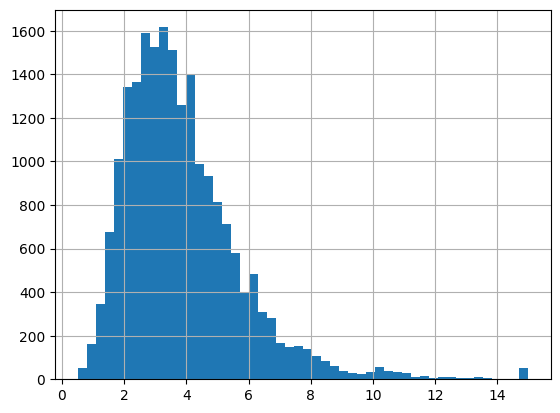

In [ ]:
_ = housing["median_income"].hist(bins=50)

La función `pd.cut` de pandas nos permite crear una nueva columna segmentando en categorías. En este caso vamos a crear 5 categorías, separando en bloques de 1,5 (excepto el último, que agrupará toda la cola gruesa de la derecha), y usaremos la función `value_counts` para ver cuántos valores hay en cada categoría.

In [ ]:
housing["income_cat"] = pd.cut(housing["median_income"],                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf], # Secuencia de límites de los contenedores                               labels=[1, 2, 3, 4, 5])

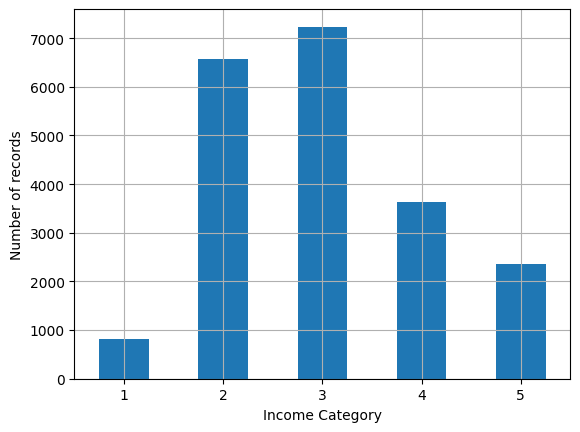

In [ ]:
import matplotlib.pyplot as plthousing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)plt.xlabel("Income Category")plt.ylabel("Number of records")plt.show()

Podemos volver a usar la función `train_test_split` de scikit-learn, pero esta vez con el parámetro `stratify` indicando la columna que queremos usar para estratificar el muestreo.

In [ ]:
strat_train_set, strat_test_set = train_test_split(    housing, test_size=0.2, stratify=housing["income_cat"],random_state=42)

Se observa que el conjunto de prueba generado con muestreo estratificado tiene una cantidad de muestras en cada estrato mucho más representativa de la población total, pese a ser aleatorio.

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Ahora podemos mostrar un DataFrame completo con los errores del muestreo aleatorio y estratificado, y comprobar que el error del muestreo estratificado es mucho menor.

In [ ]:
def income_cat_proportions(data):    return data["income_cat"].value_counts() / len(data) # proportion of valores in each income_cattrain_set, test_set = train_test_split(housing, test_size=0.2) # re-executing this cell podemos ver the variation in random splitcompare_props = pd.DataFrame({    "Overall %": income_cat_proportions(housing), # proportion of valores in each income_cat in the original dataset    "Stratified %": income_cat_proportions(strat_test_set), # proportion in the stratified test conjunto    "Random %": income_cat_proportions(test_set), # proportion in the randomly generated test conjunto}).sort_index()compare_props.index.name = "Income Category"compare_props["Strat. Error %"] = (compare_props["Stratified %"] / compare_props["Overall %"] - 1) # stratified error with respect to originalcompare_props["Rand. Error %"] = (compare_props["Random %"] / compare_props["Overall %"] - 1) # random error with respect to original(compare_props * 100).round(2) # convert all valores to percentage with two decimals

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,3.95,0.36,-0.85
2,31.88,31.88,32.41,-0.02,1.66
3,35.06,35.05,34.45,-0.01,-1.74
4,17.63,17.64,16.88,0.03,-4.23
5,11.44,11.43,12.31,-0.08,7.54


Ya que no vamos a necesitar más la variable `income_cat` (se usó solo como ayuda para estratificar), podemos eliminarla de ambos conjuntos generados.

In [ ]:
strat_train_set.drop("income_cat", axis=1, inplace=True)strat_test_set.drop("income_cat", axis=1, inplace=True)strat_train_set.head().T

,12655,15502,2908,14053,20496
longitude,-121.46,-117.23,-119.04,-117.13,-118.7
latitude,38.52,33.09,35.37,32.75,34.28
housing_median_age,29.0,7.0,44.0,24.0,27.0
total_rooms,3873.0,5320.0,1618.0,1877.0,3536.0
total_bedrooms,797.0,855.0,310.0,519.0,646.0
population,2237.0,2015.0,667.0,898.0,1837.0
households,706.0,768.0,300.0,483.0,580.0
median_income,2.1736,6.3373,2.875,2.2264,4.4964
median_house_value,72100.0,279600.0,82700.0,112500.0,238300.0
ocean_proximity,INLAND,NEAR OCEAN,INLAND,NEAR OCEAN,<1H OCEAN


## Fuga de datos (Data Leakage)

La **fuga de datos (data leakage)** es uno de los errores metodológicos más graves en Machine Learning. Ocurre siempre que se usa información procedente de fuera del conjunto de entrenamiento para crear el modelo. Esto incluye no solo el ajuste de los parámetros del modelo (pesos), sino también las decisiones de preprocesamiento, el ajuste de hiperparámetros y la selección del algoritmo.

La consecuencia de la fuga de datos es siempre la misma: las métricas de rendimiento reportadas quedan **sesgadas de forma optimista**, es decir, sobreestiman cómo funcionará el modelo con datos verdaderamente no vistos. Un modelo afectado por fuga puede parecer excelente durante el desarrollo, pero fallar de forma dramática en producción.

La fuga de datos puede clasificarse en tres tipos principales:

### 1. Fuga por características (Contaminación en el Preprocesamiento)

Ocurre cuando se usan estadísticas calculadas sobre todo el dataset (incluidos los datos de prueba) para transformar las características durante el preprocesamiento. El modelo "ve" indirectamente propiedades del conjunto de prueba a través de esas estadísticas.

**Ejemplo**: Calcular la media y desviación estándar para estandarización (normalización Z-score) usando todo el dataset y aplicarlo después a los conjuntos de entrenamiento y prueba.

```python
# MAL: Fuga a través del preprocesamiento
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)  # ¡Ajustado sobre TODOS los datos, incluido el de prueba!
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# BIEN: Ajustar solo sobre los datos de entrenamiento
scaler = StandardScaler()
scaler.fit(X_train)  # Ajustado SOLO sobre los datos de entrenamiento
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

Por eso los Pipelines de scikit-learn son esenciales: garantizan que todos los pasos de preprocesamiento se ajusten únicamente sobre los datos de entrenamiento durante la validación cruzada.

### 2. Fuga por el objetivo (Target Leakage)

Ocurre cuando una característica contiene información que deriva de (o está fuertemente correlacionada con) la variable objetivo de una manera que no estaría disponible en el momento de predecir en producción.

**Ejemplo**: Predecir si un paciente desarrollará una enfermedad usando una característica como `medicamento_X_prescrito`, que solo se receta *después* del diagnóstico. El modelo aprende la correlación, pero en producción los nuevos pacientes no tendrán aún ese atributo.

**Otro ejemplo**: En la detección de fraude, usar `cuenta_marcada_para_revisión` como característica — ese marcador puede existir *precisamente porque* el fraude ya fue detectado.

La fuga por el objetivo es especialmente insidiosa porque:
- El modelo puede alcanzar una precisión casi perfecta durante el entrenamiento
- La característica filtrada suele tener un poder predictivo muy alto (al estar codificando esencialmente la respuesta)
- Solo se detecta cuando el modelo falla en producción

**Prevención**: Auditar cuidadosamente cada característica y preguntarse: "¿Estaría disponible esta información en el momento de predecir en producción?"

### 3. Fuga en la Selección del Modelo

Ocurre cuando se usa el conjunto de prueba para comparar modelos, ajustar hiperparámetros o tomar cualquier decisión que influya en el modelo final. Aunque los datos de prueba nunca se usan directamente para el entrenamiento, la retroalimentación del rendimiento en prueba guía el proceso de selección del modelo.

**Ejemplo**: Entrenar varios modelos (Regresión Lineal, Árbol de Decisión, Random Forest), evaluar cada uno en el conjunto de prueba y elegir el que tenga el error de prueba más bajo. Luego reportar ese error de prueba como el rendimiento esperado.

**El problema**: El error de prueba reportado ya no es una estimación imparcial del rendimiento de generalización. Al seleccionar el modelo que mejor funciona en *este conjunto de prueba concreto*, estamos ajustando implícitamente a los datos de prueba. Esto se llama a menudo **sobreajuste al conjunto de prueba**.

**La solución**: Usar una **división en tres partes**:
- **Conjunto de entrenamiento**: Para ajustar los parámetros del modelo
- **Conjunto de validación**: Para comparar modelos y ajustar hiperparámetros
- **Conjunto de prueba**: Para evaluar el modelo final **una única vez**, al final de todo

Alternativamente, usar **validación cruzada** sobre el conjunto de entrenamiento para comparar modelos sin tocar en absoluto el conjunto de prueba. El conjunto de prueba debe permanecer en una "caja fuerte" hasta la evaluación final.

### Resumen: Cómo prevenir la fuga de datos

| Tipo | Qué se filtra | Prevención |
|------|--------------|------------|
| **Fuga por características** | Estadísticas del conjunto de prueba en el preprocesamiento | Usar Pipelines; ajustar transformadores solo sobre datos de entrenamiento |
| **Fuga por el objetivo** | Información futura/derivada en las características | Auditar las características verificando su validez temporal y causal |
| **Fuga en selección del modelo** | Rendimiento en prueba en la elección del modelo | Usar conjunto de validación o validación cruzada; evaluar en prueba solo una vez |

La regla de oro: **el conjunto de prueba debe simular datos verdaderamente no vistos**. Cualquier flujo de información desde la prueba hacia el entrenamiento —ya sea a través de características, preprocesamiento o retroalimentación— viola este principio e invalida la estimación del rendimiento.

## Utilidad de carga de datos

La división entrenamiento/prueba estratificada que se muestra en este notebook se consolida en una función reutilizable en [`utils/load_california.py`](utils/load_california.py). Esta función:

1. Carga los datos de vivienda desde el CSV
2. Crea categorías de ingresos para la estratificación
3. Realiza la división entrenamiento/prueba estratificada
4. Elimina la columna temporal `income_cat`
5. Separa las características (X) y el objetivo (y)

Los notebooks posteriores importan esta función para garantizar una carga de datos consistente:

```python
from utils.load_california import load_housing_data
X_train, X_test, y_train, y_test = load_housing_data()
```